# Mandatory Assignment 2

#### Student Numbers: 161612, 160364, 185903, 186634

In [4]:
# uploading packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf 

In [5]:
# loading the datasets 

eth = pd.read_csv("_eth_dkk.csv", sep=";") #have to separate by ; because eth data is separated by semicolon
novo = pd.read_csv("_XCSE_NOVO-1.csv") #this uses the default comma separator

print("Ethereum dataset:")
print(eth.head())

print("Novo Nordisk dataset:")
print(novo.head())

Ethereum dataset:
         Dato    Åbning       Høj       Lav       Luk  Volumen Markedsværdi  \
0  2025-03-01  16081.11  16394.10  15399.37  15935.94  132.89B        1.92T   
1  2025-03-02  15936.01  18330.51  15610.02  18097.15  111.54B        2.18T   
2  2025-03-03  17932.04  17970.78  14939.64  15303.53  294.59B        1.85T   
3  2025-03-04  15122.44  15635.15  14025.95  15280.70  244.05B        1.84T   
4  2025-03-05  15010.06  15715.18  14896.21  15494.54  185.41B        1.87T   

   Ændring, %  
0       -0.99  
1       13.56  
2      -15.44  
3       -0.15  
4        1.40  
Novo Nordisk dataset:
         Date     Open     High      Low    Close      Volume
0  02/27/2026  .238.00  .239.45  .236.55  .237.90  12,348,730
1  02/26/2026  .239.95  .241.70  .236.45  .238.60   9,819,212
2  02/25/2026  .243.50  .245.55  .238.00  .238.40  17,707,180
3  02/24/2026  .244.00  .248.00  .240.40  .243.65  22,654,199
4  02/23/2026  .300.00  .300.90  .251.30  .251.40  35,951,793


In [6]:
# looking at the shape and column names of the datasets

print("Ethereum dataset:")
print("Shape:", eth.shape)
print("Columns:", eth.columns.tolist())

print("Novo Nordisk dataset:")
print("Shape:", novo.shape)
print("Columns:", novo.columns.tolist())

Ethereum dataset:
Shape: (366, 8)
Columns: ['Dato', 'Åbning', 'Høj', 'Lav', 'Luk', 'Volumen', 'Markedsværdi', 'Ændring, %']
Novo Nordisk dataset:
Shape: (250, 6)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']


##### Variables in the Ethereum dataset:

Åbning = opening price

Høj = highest price

Lav = lowest price

Luk = closing price

Ændring, % = Percentage change

Volumen = Volume

Markedsværdi = market cap


In [7]:
# checking for the datatypes in both sets

print("Ethereum data types:")
print(eth.dtypes)

print("\nNovo data types:")
print(novo.dtypes)

Ethereum data types:
Dato             object
Åbning          float64
Høj             float64
Lav             float64
Luk             float64
Volumen          object
Markedsværdi     object
Ændring, %      float64
dtype: object

Novo data types:
Date      object
Open      object
High      object
Low       object
Close     object
Volume    object
dtype: object


In [8]:
# converting novo data types to numerical (float)

novo["Open"] = novo["Open"].str.replace(".", "", regex=False).astype(float) / 100 #with regex=False pandas reads "." as a normal dot not any character
novo["High"] = novo["High"].str.replace(".", "", regex=False).astype(float) / 100
novo["Low"] = novo["Low"].str.replace(".", "", regex=False).astype(float) / 100
novo["Close"] = novo["Close"].str.replace(".", "", regex=False).astype(float) / 100
novo["Volume"] = novo["Volume"].str.replace(",", "", regex=False).astype(int)

In [9]:
# checking the date ranges for each dataset

# Ethereum date range
print("Ethereum start date:", eth["Dato"].min())
print("Ethereum end date:", eth["Dato"].max())

# Novo date range
print("Novo start date:", novo["Date"].min())
print("Novo end date:", novo["Date"].max())

#the output doesn't make sense because the novo date column is treated as text, have to convert

Ethereum start date: 2025-03-01
Ethereum end date: 2026-03-01
Novo start date: 01/02/2026
Novo end date: 12/30/2025


In [10]:
# converting date columns to datetime format

eth["Dato"] = pd.to_datetime(eth["Dato"])
novo["Date"] = pd.to_datetime(novo["Date"])

# checking date ranges again

print("Ethereum start date:", eth["Dato"].min())
print("Ethereum end date:", eth["Dato"].max())

print("Novo start date:", novo["Date"].min())
print("Novo end date:", novo["Date"].max())

#sorting by date

eth = eth.sort_values("Dato")
novo = novo.sort_values("Date")

Ethereum start date: 2025-03-01 00:00:00
Ethereum end date: 2026-03-01 00:00:00
Novo start date: 2025-02-27 00:00:00
Novo end date: 2026-02-27 00:00:00


Both datasets cover exactly a one year period, so we don't have to filter to common date range and can just calculate ROI using the first and last closing price in each dataset.

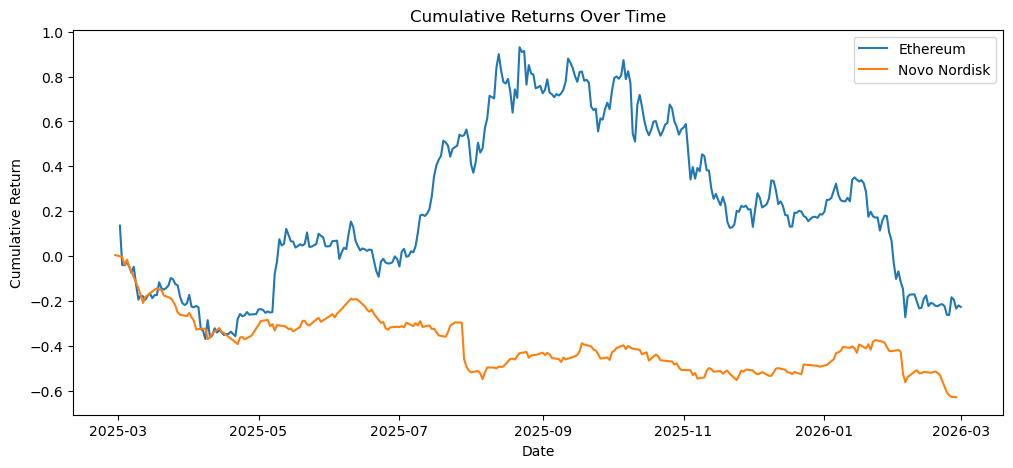

In [11]:
# comparing the cumulative returns over time of ethereum and novo

# calculate daily returns
eth["daily_return"] = eth["Luk"].pct_change()
novo["daily_return"] = novo["Close"].pct_change()

# calculate cumulative returns
eth["cum_return"] = (1 + eth["daily_return"]).cumprod() - 1
novo["cum_return"] = (1 + novo["daily_return"]).cumprod() - 1

# plot cumulative returns
plt.figure(figsize=(12, 5))
plt.plot(eth["Dato"], eth["cum_return"], label="Ethereum")
plt.plot(novo["Date"], novo["cum_return"], label="Novo Nordisk")
plt.title("Cumulative Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()

### Question 1

#### Asset Selection: Should you invest in cryptocurrency (Ethereum) or in equity (Novo Nordisk stock)?

In [12]:
# for the ROI calculation, we take the first and last closing prices
eth_start = eth["Luk"].iloc[0]
eth_end = eth["Luk"].iloc[-1]

novo_start = novo["Close"].iloc[0]
novo_end = novo["Close"].iloc[-1]

# now calculating the ROI
eth_roi = (eth_end - eth_start) / eth_start
novo_roi = (novo_end - novo_start) / novo_start

print("Ethereum ROI:", eth_roi)
print("Novo Nordisk ROI:", novo_roi)

Ethereum ROI: -0.2269649609624534
Novo Nordisk ROI: -0.6293237768775319


In [13]:
# looking at the total investment value, how much money we would have by the end of the period if we invested in either asset

investment = 250000

eth_value = investment * (1 + eth_roi)
novo_value = investment * (1 + novo_roi)

print("Ethereum final value:", eth_value)
print("Novo final value:", novo_value)

Ethereum final value: 193258.75975938668
Novo final value: 92669.05578061701


Based on the historical ROI, Ethereum would be the better choice compared to Novo Nordisk, because it generated a smaller loss over the one year period. However, both assets performed very badly: Ethereum returned -22.7% and Novo Nordisk returned about -62.9%, meaning that a 250,000 investment would have lost substantial value in both cases. In hindsight, these returns make it seem like shorting both assets would have been a better idea :)

### Question 2

#### Capital Allocation Strategy: How should the DKK 250,000 be allocated? Should you adopt a pure strategy (100% allocation to one asset) or a hybrid strategy (e.g., X% in cryptocurrency and Y% in stock)? What is the appropriate investment horizon (short-term vs. long-term; months vs. years)?

To answer this question, we will look at a variety of metrics, namely performance during different market regimes, anomaly detection, supervised machine learing model of logistic regression to predict next-day returns, different portfolio allocation proprtions and finally a comparison of average monthly returns.

Ethereum regime summary
              mean       std  count
regime                             
high_vol -0.000334  0.047341    168
low_vol   0.000510  0.034529    197

Novo Nordisk regime summary
              mean       std  count
regime                             
high_vol -0.001416  0.044986    110
low_vol  -0.004827  0.025544    139


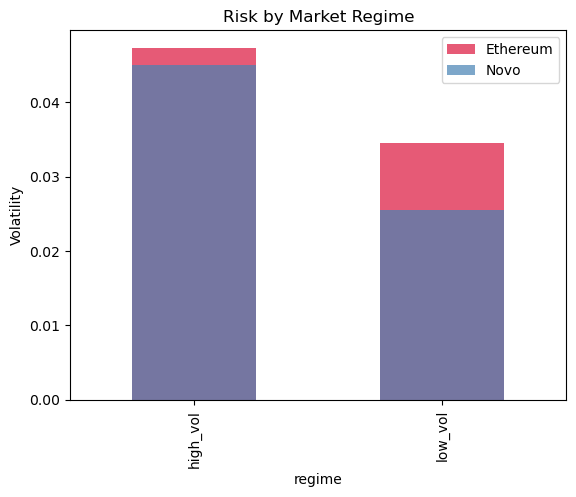

In [14]:
# Look at market regimes (high vs low volatility)

# calculate rolling volatility

eth["Return"] = eth["Luk"].pct_change() # calculate daily returns for ethereum
novo["Return"] = novo["Close"].pct_change() # calculate daily returns for novo

eth["volatility"] = eth["Return"].rolling(30).std() # calculate 30-day rolling volatility for ethereum
novo["volatility"] = novo["Return"].rolling(30).std() # calculate 30-day rolling volatility for novo

# define regimes

eth["regime"] = np.where(eth["volatility"] > eth["volatility"].median(), # if volatility is higher than median it is high_vol, if not low_vol
                         "high_vol",
                         "low_vol")

novo["regime"] = np.where(novo["volatility"] > novo["volatility"].median(),
                          "high_vol",
                          "low_vol")

# create regime summary tables to compare returns across regimes

eth_summary = eth.groupby("regime")["Return"].agg(["mean","std","count"]) # group by regime and calculate statistics
novo_summary = novo.groupby("regime")["Return"].agg(["mean","std","count"])

print("Ethereum regime summary")
print(eth_summary)

print("\nNovo Nordisk regime summary")
print(novo_summary)

# visualize regime risk

eth.groupby("regime")["Return"].std().plot(
    kind="bar", alpha=0.7, label="Ethereum", color="crimson"
)

novo.groupby("regime")["Return"].std().plot(
    kind="bar", alpha=0.7, label="Novo", color="steelblue"
)

plt.ylabel("Volatility")
plt.title("Risk by Market Regime")
plt.legend()
plt.show()

The regime analysis shows us that Ethereum produces positive returns only in the low-volatility regime, suggesting it should be held mainly during calmer periods. Novo Nordisk has lower volatility overall, making it the more stable asset. The visualization supports this, showing that Ethereum is consistently more volatile than Novo Nordisk and both assets become significantly less risky in the low-volatility regime. A reasonable strategy would therefore be to allocate a larger share to Novo Nordisk for stability and a smaller share to Ethereum for growth potential, with higher Ethereum exposure during low-volatility regimes.

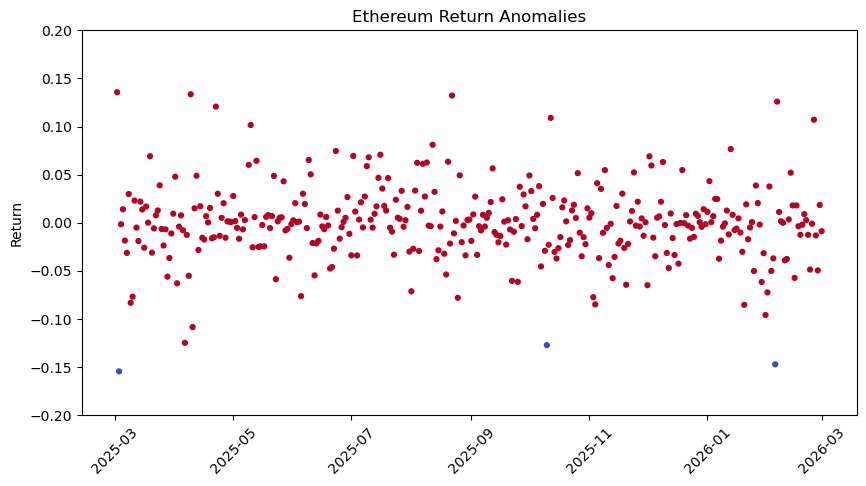

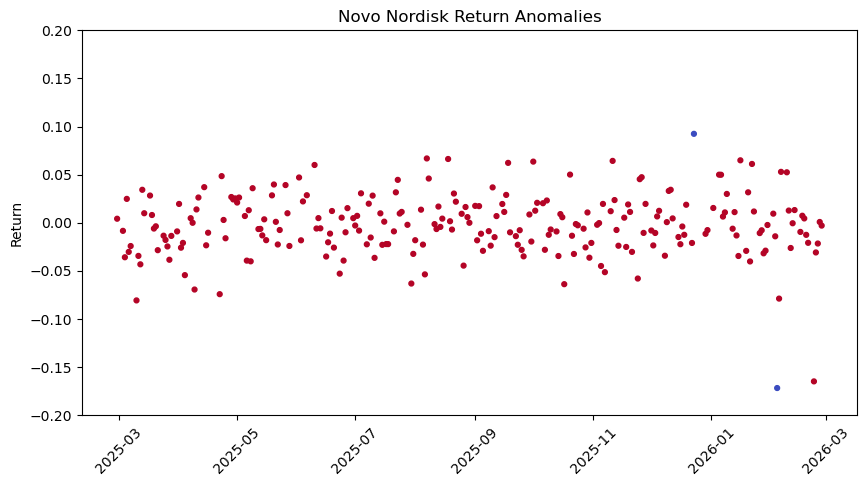

In [15]:
# Using isolation forest to detect anomalies in returns (extreme events)

from sklearn.ensemble import IsolationForest

# Ethereum
iso_eth = IsolationForest(contamination=0.01, random_state=42) # isolation forest for ethereum with 1% anomalies
eth_nonan = eth[["Return"]].dropna() # remove rows containing missing values (for returns the first row is always NaN)          
eth.loc[eth_nonan.index, "anomaly"] = iso_eth.fit_predict(eth_nonan) # fit data and predict anomalies

# Novo
iso_novo = IsolationForest(contamination=0.01, random_state=42) 
novo_nonan = novo[["Return"]].dropna()
novo.loc[novo_nonan.index, "anomaly"] = iso_novo.fit_predict(novo_nonan)

# visualize anomalies 

plt.figure(figsize=(10,5))
plot_eth = eth.dropna(subset=["anomaly"])

plt.scatter(
    plot_eth["Dato"],
    plot_eth["Return"],
    c=plot_eth["anomaly"],
    cmap="coolwarm",
    s=12
)

plt.title("Ethereum Return Anomalies")
plt.ylabel("Return")
plt.ylim(-0.2, 0.2)  # set same y-axis scale for both graphs to make comparison easier
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
plot_novo = novo.dropna(subset=["anomaly"])

plt.scatter(
    plot_novo["Date"],
    plot_novo["Return"],
    c=plot_novo["anomaly"],
    cmap="coolwarm",
    s=12
)

plt.title("Novo Nordisk Return Anomalies")
plt.ylabel("Return")
plt.ylim(-0.2, 0.2)  
plt.xticks(rotation=45)
plt.show()

Ethereum exhibits a larger range and more frequent extreme return events, indicating higher risk and greater volatility. Novo Nordisk shows more stable return behavior, with most observations clustered close to zero. This supports allocating a larger share of the portfolio to Novo Nordisk for stability, while keeping a smaller allocation to Ethereum for potential spikes.

In [16]:
# Create logistic regression algorithm to predict next day returns, this will show us how easy the returns are to predict, and also if they are likely to be positive or negative

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# clean Ethereum volume column as it contains numbers and letters, so we can work with it later
eth["Volumen"] = eth["Volumen"].astype(str).replace({"B":"e9","M":"e6","K":"e3"}, regex=True) # convert to string to use str.replace and convert letters to scientific notation e.g. B (billions) --> e9
eth["Volumen"] = pd.to_numeric(eth["Volumen"], errors="coerce") # convert scientific notation to numeric

# create prediction target
eth["target"] = (eth["Return"].shift(-1) > 0).astype(int) # check if return is positive, if positive return = 1, if negative return = 0
novo["target"] = (novo["Return"].shift(-1) > 0).astype(int)

def run_logistic_model(df, feature_cols, name): # create function for regressor to not write it twice
    # prepare data
    data = df[feature_cols + ["target"]].dropna() # data is made up of predictor columns and target column, remove missing values
    X = data[feature_cols]
    y = data["target"]

    # split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # train model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # test accuracy
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name} accuracy:", acc)

    # use model
    latest_X = X.tail(1) # use the most recent observation to make a prediction
    prediction = model.predict(latest_X) # predict direction of next return
    probability = model.predict_proba(latest_X) # predict probability of positive return

    # print observations
    print(name, "next-day prediction:", "Positive return" if prediction[0] == 1 else "Negative return")
    print(name, "probability of positive return:", round(probability[0,1], 3))

    return model 
    
# run for Ethereum
model_eth = run_logistic_model(
    eth, # choose eth as df
    ["Åbning", "Høj", "Lav", "Luk", "Volumen"], # which columns should be used
    "Ethereum"
)

# run for Novo
model_novo = run_logistic_model(
    novo, # use novo as df
    ["Open", "High", "Low", "Close", "Volume"], # predictor columns
    "Novo Nordisk"
)

Ethereum accuracy: 0.5
Ethereum next-day prediction: Negative return
Ethereum probability of positive return: 0.488
Novo Nordisk accuracy: 0.52
Novo Nordisk next-day prediction: Negative return
Novo Nordisk probability of positive return: 0.447


The logistic regression results indicate that next-day returns for both Ethereum and Novo Nordisk are difficult to predict. The accuracies of 0.50 for Ethereum and 0.52 for Novo Nordisk suggest that the available data provides limited predictive power, with Novo Nordisk being slightly more predictable. The model predicts a negative return for both assets, but with low confidence. This implies that short-term predictions should not guide investment decisions, and a hybrid portfolio allocation between the two assets is more appropriate.


In [17]:
# Try different portfolio allocation proportions

# combine return series into one dataframe
portfolio_data = pd.DataFrame({
    "ETH": eth["Return"],
    "NOVO": novo["Return"]
}).dropna()

# define different portfolio weights
weights = [
    (1.0, 0.0),   # 100% ETH
    (0.8, 0.2),   # 80% ETH, 20% NOVO
    (0.5, 0.5),   # 50% ETH, 50% NOVO
    (0.2, 0.8),   # 20% ETH, 80% NOVO
    (0.0, 1.0)    # 100% NOVO
]

results = [] # empty list to store results

for w_eth, w_novo in weights: # loop through each allocation 
    portfolio_return = w_eth * portfolio_data["ETH"] + w_novo * portfolio_data["NOVO"] # calculate daily portfolio return
    
    mean_return = portfolio_return.mean() # calculate average daily portfolio return
    volatility = portfolio_return.std() # calculate standard deviation of portfolio (volatility)
    
    # cumulative growth of 250,000 DKK using average daily return
    final_value = 250000 * (1 + mean_return)
    
    results.append([w_eth, w_novo, mean_return, volatility, final_value]) # add to empty list

allocation_results = pd.DataFrame( # convert list into structured table (dataframe) and print
    results,
    columns=["ETH_weight", "NOVO_weight", "Mean_Return", "Volatility", "Estimated_Value"]
)

print(allocation_results)

   ETH_weight  NOVO_weight  Mean_Return  Volatility  Estimated_Value
0         1.0          0.0     0.002059    0.042181    250514.736290
1         0.8          0.2     0.000983    0.034463    250245.704843
2         0.5          0.5    -0.000631    0.027526    249842.157672
3         0.2          0.8    -0.002246    0.029605    249438.610502
4         0.0          1.0    -0.003322    0.035504    249169.579055


The results show that a 100% Ethereum portfolio has the highest mean return, but also the highest volatility, indicating the greatest potential return but also the highest risk. As the allocation shifts toward Novo Nordisk, both the mean return and volatility decrease, highlighting a clear risk–return trade-off. For example, an 80/20 ETH–Novo portfolio maintains a relatively high mean return while reducing volatility compared to the fully Ethereum portfolio.

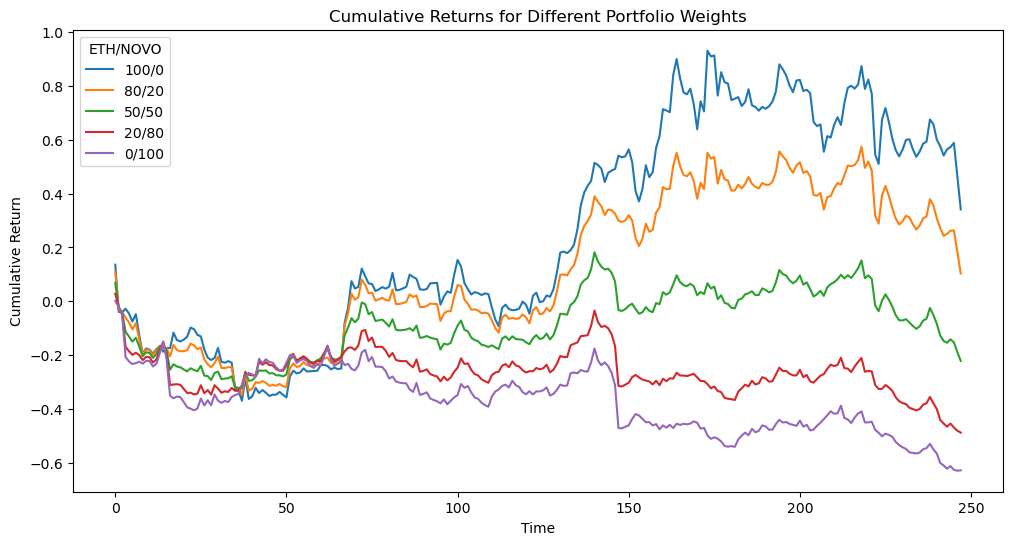

In [18]:
# Visualizing cumulative returns of different portfolio allocations

plt.figure(figsize=(12, 6))

for w_eth, w_novo in weights:
    portfolio_return = w_eth * portfolio_data["ETH"] + w_novo * portfolio_data["NOVO"]
    cumulative_return = (1 + portfolio_return).cumprod() - 1
    
    label = f"{int(w_eth*100)}/{int(w_novo*100)}"
    plt.plot(cumulative_return.values, label=label)

plt.title("Cumulative Returns for Different Portfolio Weights")
plt.xlabel("Time")
plt.ylabel("Cumulative Return")
plt.legend(title="ETH/NOVO")
plt.show()

The chart shows that portfolios with a higher share of Ethereum (100/0 and 80/20) get the highest cumulative returns over time. In contrast, portfolios with a larger share of Novo Nordisk perform worse and remain mostly negative throughout the period. This suggests that Ethereum drives most of the portfolio growth, while Novo Nordisk mainly reduces overall returns but can provide diversification and stability.

In [19]:
# Look at monthly average returns to better understand the time series

# extract year-month from the date columns
eth["month"] = pd.to_datetime(eth["Dato"]).dt.to_period("M")
novo["month"] = pd.to_datetime(novo["Date"]).dt.to_period("M")

# group by month and calculate the average return for each month
eth_monthly = eth.groupby("month")["Return"].mean()
novo_monthly = novo.groupby("month")["Return"].mean()

# show summary statistics of the monthly returns
print("Ethereum monthly average return:")
print(eth_monthly.describe())

print("\n Novo monthly average return:")
print(novo_monthly.describe())

Ethereum monthly average return:
count    13.000000
mean     -0.000635
std       0.007357
min      -0.008759
25%      -0.006359
50%      -0.001308
75%      -0.000177
max       0.014369
Name: Return, dtype: float64

 Novo monthly average return:
count    13.000000
mean     -0.002679
std       0.008313
min      -0.020038
25%      -0.003440
50%      -0.001266
75%       0.002375
max       0.006722
Name: Return, dtype: float64


Overall, the monthly statistics suggest that both time series show large variability and no consistent positive trend over the period, meaning returns fluctuate significantly from month to month. This reinforces the earlier findings that short-term movements are difficult to predict and performance varies across time, which supports using a longer investment horizon and diversified portfolio strategy.

#### Answer:

In conclusion, the results show that Ethereum has higher return potential but also higher volatility, while Novo Nordisk is more stable but gives lower returns. Ethereum also experiences larger and more frequent price movements, while Novo Nordisk returns are generally more concentrated around zero. In addition, the prediction model shows that next-day returns for both are difficult to predict, meaning that short-term trading strategies are not likely to work well.

The portfolio analysis shows a clear trade-off between return and risk. Portfolios with a larger share of Ethereum generate higher average returns but also higher volatility. Increasing the share of Novo Nordisk reduces risk but also lowers expected returns. For example, an 80% Ethereum and 20% Novo Nordisk portfolio still achieves relatively high returns while reducing volatility compared to investing fully in Ethereum.

Overall, the results suggest that a hybrid portfolio strategy is better than investing only in one asset. Investing the full 250,000 DKK in Ethereum would give the highest potential return but also expose the investor to high risk, while investing only in Novo Nordisk would be more stable but offer lower returns. A portfolio with a larger share in Ethereum and a smaller share in Novo Nordisk provides a better balance between growth and stability.

Regarding the investment horizon, the results show that short-term returns are difficult to predict and can fluctuate a lot over time. Therefore, the investment should be held over a longer period, such as several months or years, rather than focusing on short-term trading.


## Question 3

### Are there identifiable seasonal patterns or cyclical trends in cryp-tocurrency and stock returns? For example, are there specific months or periods that historically yield higher average returns, suggesting a more favorable entry point?

In [20]:
# extracting months
eth["month_num"] = pd.to_datetime(eth["Dato"]).dt.month
novo["month_num"] = pd.to_datetime(novo["Date"]).dt.month

# calculating average monthly return for crypto and stock
eth_seasonality = eth.groupby("month_num")["Return"].mean()
novo_seasonality = novo.groupby("month_num")["Return"].mean()

print("Ethereum average return by month:")
print(eth_seasonality)

print("\nNovo Nordisk average return by month:")
print(novo_seasonality)

Ethereum average return by month:
month_num
1    -0.005877
2    -0.006359
3    -0.006723
4    -0.000804
5     0.012203
6    -0.001308
7     0.014369
8     0.005805
9    -0.001713
10   -0.001026
11   -0.007956
12   -0.000177
Name: Return, dtype: float64

Novo Nordisk average return by month:
month_num
1     0.006580
2    -0.018883
3    -0.014594
4    -0.003440
5     0.002375
6    -0.001266
7    -0.012870
8     0.006722
9    -0.001542
10   -0.003381
11    0.000684
12    0.001729
Name: Return, dtype: float64


Initially, by only looking at the numbers of average return by month it is difficult to identify any clear seasonality or trends. The values are mostly small and close to zero for both Ethereum and Novo, making it hard to spot patterns, so we visualized it using bar charts. 

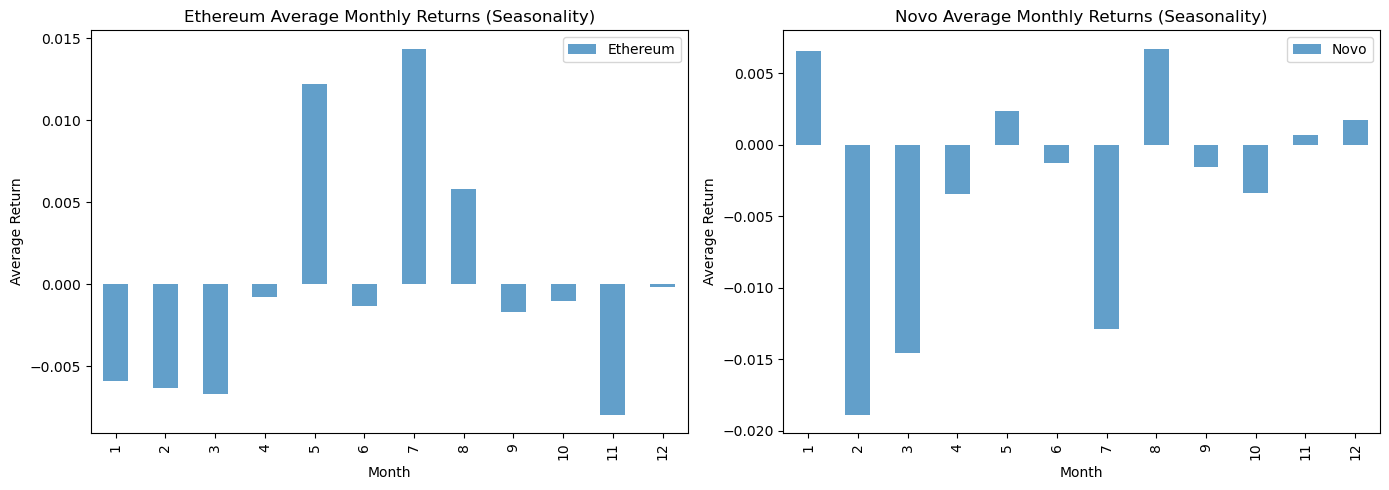

In [22]:
# figure with two side by side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# bar chart for Ethereum 
eth_seasonality.plot(kind="bar", alpha=0.7, label="Ethereum", ax=ax1)
ax1.set_xlabel("Month")
ax1.set_ylabel("Average Return")
ax1.set_title("Ethereum Average Monthly Returns (Seasonality)")
ax1.legend()

# bar chart for Novo
novo_seasonality.plot(kind="bar", alpha=0.7, label="Novo", ax=ax2)
ax2.set_xlabel("Month")
ax2.set_ylabel("Average Return")
ax2.set_title("Novo Average Monthly Returns (Seasonality)")
ax2.legend()

plt.tight_layout()
plt.show()

Ethereum shows a consistent negative stretch across January to March and a dip again in November. There are three notable positive spikes in May, July and August. The remaining months are a bit below zero. Novo behaves differently, as January and August are the strongest positive months (although their returns are still significantly lower than Ethereum's peaks), while February, March and July stand out as the worst performing months (with significantly stronger losses than in Ethereum). The swings between months are larger for Novo, which can be surprising, as stock returns seem to be more stable than crypto ones. 
Despite these observations, it is clear by the graphs of both events, that neither of them displays seasonality. Ethereum's mid-year positive months and Novo's early-year negative months are the most notable observations, but these should not be interpreted as reliable seasonal patterns. The dataset only covers one year. To draw any conclusions about seasonality, at least 3 to 5 years of data would be needed. Even then, based on what is visible here, the returns for both assets appear largely random and unstable, with no consistent recurring structure. 

In [33]:
# extract month from dates
eth["month"] = pd.to_datetime(eth["Dato"]).dt.month
novo["month"] = pd.to_datetime(novo["Date"]).dt.month

# target variable (1 = next day's return is positive, 0 = when return is negative)
eth["target"] = (eth["Return"].shift(-1) > 0).astype(int)
novo["target"] = (novo["Return"].shift(-1) > 0).astype(int)

# Ethereum model for coefficient
eth_data = eth[["month","target"]].dropna()

X_eth = eth_data[["month"]]
y_eth = eth_data["target"]

model_eth = LogisticRegression()
model_eth.fit(X_eth, y_eth)

print("Ethereum coefficient for month:", model_eth.coef_)

# Novo Nordisk model for coefficient
novo_data = novo[["month","target"]].dropna()

X_novo = novo_data[["month"]]
y_novo = novo_data["target"]

model_novo = LogisticRegression()
model_novo.fit(X_novo, y_novo)

print("Novo coefficient for month:", model_novo.coef_)

Ethereum coefficient for month: [[0.00740432]]
Novo coefficient for month: [[0.0101241]]


The code above runs a logistic regression to check whether the month of the year can predict if the next period's return will be positive or negative. A coefficient of 0,01 means that from going from one month to the next one changes the log odds of a positive return by just 0,01, which translates to a probability change of less than 0,25%, which is essentially a meaningless change. Both Ethereum and Novo show coefficients very close to zero, indicating little to no predictive power from the month alone. Novo's coefficient is slightly higher, which could suggest that stock returns are slightly more structured than crypto, but it is still negligible. However, these results should be interpreted with caution as the dataset only covers one year, which is not enough for reliable conclusions about seasonality.

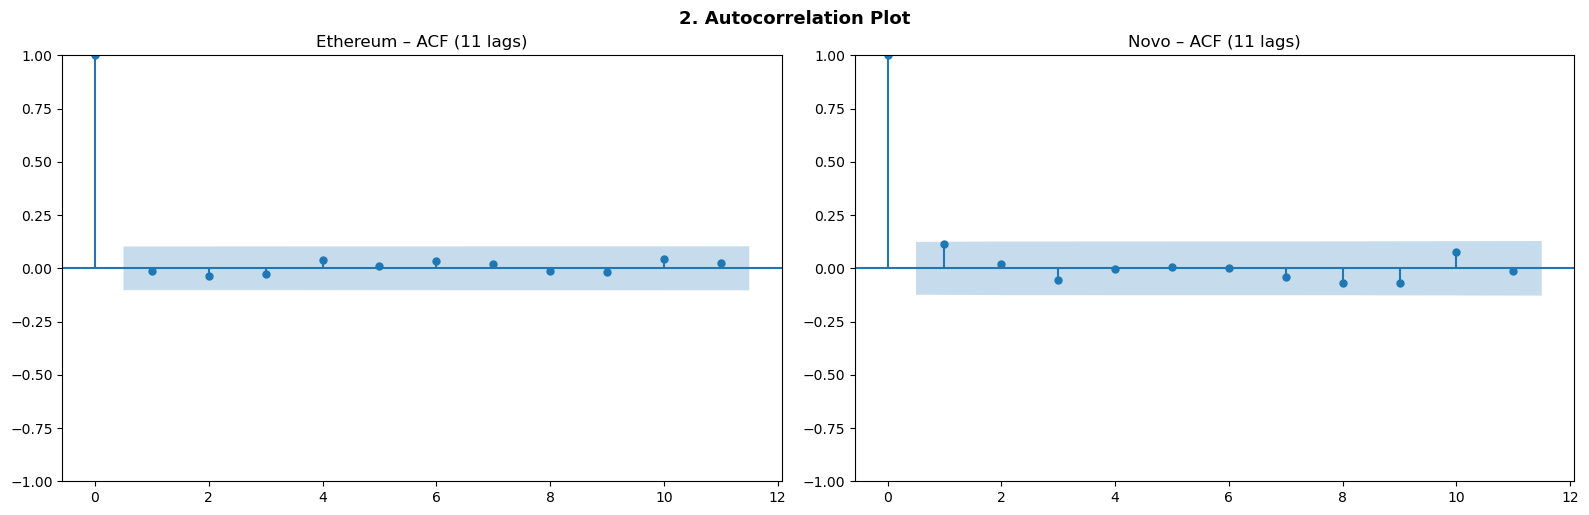

In [35]:
# figure with two side by side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# plotting ACF for Ethereum with 11 lags (max possible with one year of data; each lag represents one month back)
plot_acf(eth["Return"].dropna(),  lags=11, ax=axes[0], title="Ethereum – ACF (11 lags)")

# plotting ACF for Novo with 11 lags
plot_acf(novo["Return"].dropna(), lags=11, ax=axes[1], title="Novo – ACF (11 lags)")

plt.tight_layout()
plt.suptitle("2. Autocorrelation Plot", y=1.02, fontsize=13, fontweight="bold")
plt.show()

The ACF (autocorrelation function) measures the correlation between observations in a time series at different lags. It's used to detect patterns and seasonality. In this case it measures whether this month's return is correlated with returns from previous months. For Ethereum, all lags fall within the confidence band, indicating that there is no correlation between current and past returns. For Novo, there is a small spike at lag 1 that slightly exceeds the band, suggesting a very weak relationship between consecutive months, but it is too small to be meaningful. Overall, both events confirm what the bar charts already showed, returns appear random with no statistically significant autocorrelation, and therefore there is no visible seasonality.

### Answer

Neither Ethereum or Novo display any meaningful seasonality. All three methods: bar charts with monthly returns, calculating logistic regression and ACF consistently give us the same conclusion. Returns for both assets are largely random with no statistically significant repeating patterns. However, any observations made are not fully reliable as the dataset only covers one year. At least 3 years of data would be needed to draw any real conclusions which should be taken into consideration when making any decision based on these results and observations. 